In [33]:
# ============================================================
# Imports and notebook settings
#
# Purpose:
# Load required libraries for data processing, visualization,
# statistical analysis, and Isolation Forest anomaly detection.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.float_format", "{:,.2f}".format)

## Read source data

In [34]:
# ============================================================
# Read source CSV files
#
# Purpose:
# Load AWS CUR cost data and Kubernetes metrics data.
# AWS data is the main source for cost anomalies.
# Kubernetes metrics are used to enrich the analysis with
# infrastructure workload context.
# ============================================================

aws_cur_path = "../synnepha_exercise_90d/synnepha_exercise_aws_cur_sample_90d.csv"
k8s_metrics_path = "../synnepha_exercise_90d/synnepha_exercise_k8s_metrics_90d.csv"

aws_cur_df = pd.read_csv(aws_cur_path)
k8s_metrics_df = pd.read_csv(k8s_metrics_path)

print("AWS CUR shape:", aws_cur_df.shape)
print("Kubernetes metrics shape:", k8s_metrics_df.shape)

display(aws_cur_df.head())
display(k8s_metrics_df.head())

AWS CUR shape: (8100, 8)
Kubernetes metrics shape: (15120, 8)


,billing_period,date,account_id,service,usage_type,region,cost_usd,usage_quantity
0,2026-01,2026-01-31,acct_001,AmazonEC2,BoxUsage:m5.xlarge,us-east-1,927.48,"4,780.38"
1,2026-01,2026-01-31,acct_001,AmazonEC2,BoxUsage:m5.xlarge,eu-west-1,948.28,"4,985.43"
2,2026-01,2026-01-31,acct_001,AmazonS3,TimedStorage-ByteHrs,us-east-1,249.25,"10,695,835.07"
3,2026-01,2026-01-31,acct_001,AmazonS3,TimedStorage-ByteHrs,eu-west-1,287.45,"12,458,092.77"
4,2026-01,2026-01-31,acct_001,AmazonRDS,InstanceUsage:db.r5.large,us-east-1,592.14,"2,446.20"


,timestamp,pod_name,namespace,node,cpu_usage_cores,memory_usage_mb,cpu_request_cores,memory_request_mb
0,2026-01-31T00:00:00Z,api-gateway-7f8d9,production,node-01,0.13,199.10,0.50,512
1,2026-01-31T00:00:00Z,batch-processor-1d5f3,production,node-01,0.38,976.10,1.00,2048
2,2026-01-31T00:00:00Z,cache-layer-5f1d9,production,node-01,0.24,484.10,0.50,1024
3,2026-01-31T00:00:00Z,data-pipeline-4a2c1,production,node-02,0.78,"1,912.10",2.00,4096
4,2026-01-31T00:00:00Z,legacy-etl-2e7b4,production,node-03,0.05,86.20,2.00,4096


## Parse date columns

In [35]:
# ============================================================
# Parse date and timestamp columns
#
# Purpose:
# Convert date columns into datetime format and normalize
# Kubernetes timestamps to timezone-naive daily dates.
#
# Why:
# AWS CUR uses daily dates, while Kubernetes timestamps may have
# UTC timezone information. Normalizing both prevents merge errors.
# ============================================================

aws_cur_df["date"] = pd.to_datetime(aws_cur_df["date"])

k8s_metrics_df["timestamp"] = (
    pd.to_datetime(k8s_metrics_df["timestamp"], utc=True)
    .dt.tz_localize(None)
)

k8s_metrics_df["date"] = k8s_metrics_df["timestamp"].dt.floor("D")

print("AWS date range:", aws_cur_df["date"].min(), "to", aws_cur_df["date"].max())
print("K8s date range:", k8s_metrics_df["date"].min(), "to", k8s_metrics_df["date"].max())

print("\nDate dtypes:")
print("AWS:", aws_cur_df["date"].dtype)
print("K8s:", k8s_metrics_df["date"].dtype)

AWS date range: 2026-01-31 00:00:00 to 2026-04-30 00:00:00
K8s date range: 2026-01-31 00:00:00 to 2026-04-30 00:00:00

Date dtypes:
AWS: datetime64[ns]
K8s: datetime64[ns]


In [36]:
k8s_metrics_df.head()

,timestamp,pod_name,namespace,node,cpu_usage_cores,memory_usage_mb,cpu_request_cores,memory_request_mb,date
0,2026-01-31,api-gateway-7f8d9,production,node-01,0.13,199.10,0.50,512,2026-01-31
1,2026-01-31,batch-processor-1d5f3,production,node-01,0.38,976.10,1.00,2048,2026-01-31
2,2026-01-31,cache-layer-5f1d9,production,node-01,0.24,484.10,0.50,1024,2026-01-31
3,2026-01-31,data-pipeline-4a2c1,production,node-02,0.78,"1,912.10",2.00,4096,2026-01-31
4,2026-01-31,legacy-etl-2e7b4,production,node-03,0.05,86.20,2.00,4096,2026-01-31


## Basic data validation

In [37]:
# ============================================================
# Basic data validation
#
# Purpose:
# Check data quality before feature engineering and modelling.
#
# Checks:
# - Missing values
# - Duplicate rows
# - Negative cost or usage
# - Negative Kubernetes resource metrics
# ============================================================

print("AWS CUR missing values:")
display(aws_cur_df.isna().sum())

print("\nKubernetes metrics missing values:")
display(k8s_metrics_df.isna().sum())

print("\nAWS duplicate rows:", aws_cur_df.duplicated().sum())
print("K8s duplicate rows:", k8s_metrics_df.duplicated().sum())

print("\nNegative AWS cost rows:")
display(aws_cur_df[aws_cur_df["cost_usd"] < 0])

print("\nNegative AWS usage rows:")
display(aws_cur_df[aws_cur_df["usage_quantity"] < 0])

print("\nNegative Kubernetes metric rows:")
display(
    k8s_metrics_df[
        (k8s_metrics_df["cpu_usage_cores"] < 0) |
        (k8s_metrics_df["memory_usage_mb"] < 0) |
        (k8s_metrics_df["cpu_request_cores"] < 0) |
        (k8s_metrics_df["memory_request_mb"] < 0)
    ]
)

AWS CUR missing values:


billing_period    0
date              0
account_id        0
service           0
usage_type        0
region            0
cost_usd          0
usage_quantity    0
dtype: int64


Kubernetes metrics missing values:


timestamp            0
pod_name             0
namespace            0
node                 0
cpu_usage_cores      0
memory_usage_mb      0
cpu_request_cores    0
memory_request_mb    0
date                 0
dtype: int64


AWS duplicate rows: 0
K8s duplicate rows: 0

Negative AWS cost rows:


,billing_period,date,account_id,service,usage_type,region,cost_usd,usage_quantity



Negative AWS usage rows:


,billing_period,date,account_id,service,usage_type,region,cost_usd,usage_quantity



Negative Kubernetes metric rows:


,timestamp,pod_name,namespace,node,cpu_usage_cores,memory_usage_mb,cpu_request_cores,memory_request_mb,date


## Daily AWS feature engineering

In [38]:
# ============================================================
# Aggregate AWS CUR data at daily level
#
# Purpose:
# Create daily cost and usage features for anomaly detection.
#
# These features are used by:
# - Rolling statistics
# - Isolation Forest
# - Root-cause and visualization steps
# ============================================================

daily_aws_df = (
    aws_cur_df
    .groupby("date", as_index=False)
    .agg(
        total_cost_usd=("cost_usd", "sum"),
        mean_cost_usd=("cost_usd", "mean"),
        max_cost_usd=("cost_usd", "max"),
        total_usage_quantity=("usage_quantity", "sum"),
        mean_usage_quantity=("usage_quantity", "mean"),
        unique_accounts=("account_id", "nunique"),
        unique_services=("service", "nunique"),
        unique_regions=("region", "nunique"),
        unique_usage_types=("usage_type", "nunique")
    )
    .sort_values("date")
)

display(pd.concat([daily_aws_df.head(), daily_aws_df.tail()]))

,date,total_cost_usd,mean_cost_usd,max_cost_usd,total_usage_quantity,mean_usage_quantity,unique_accounts,unique_services,unique_regions,unique_usage_types
0,2026-01-31,"16,862.60",187.36,"1,025.91","133,458,592.40","1,482,873.25",8,6,4,6
1,2026-02-01,"17,107.44",190.08,"1,002.68","133,314,383.86","1,481,270.93",8,6,4,6
2,2026-02-02,"24,095.45",267.73,"1,612.40","211,286,400.58","2,347,626.67",8,6,4,6
3,2026-02-03,"23,620.45",262.45,"1,777.13","201,351,235.12","2,237,235.95",8,6,4,6
4,2026-02-04,"23,736.00",263.73,"1,638.11","209,291,301.51","2,325,458.91",8,6,4,6
85,2026-04-26,"17,512.82",194.59,"1,141.98","132,209,617.13","1,468,995.75",8,6,4,6
86,2026-04-27,"23,640.68",262.67,"1,655.50","201,351,198.82","2,237,235.54",8,6,4,6
87,2026-04-28,"26,272.61",291.92,"1,669.97","242,693,748.28","2,696,597.20",8,6,4,6
88,2026-04-29,"27,743.61",308.26,"2,124.27","235,347,154.37","2,614,968.38",8,6,4,6
89,2026-04-30,"27,440.17",304.89,"1,777.20","236,192,537.30","2,624,361.53",8,6,4,6


## 7-day rolling cost features

In [39]:
# ============================================================
# Create 7-day rolling cost features
#
# Purpose:
# Capture short-term cost deviations compared with recent history.
#
# Why 7 days:
# Cloud workloads often have weekly patterns.
# A 7-day window is more responsive than 14 days and better
# captures short-term operational changes in this dataset.
# ============================================================

daily_aws_df["cost_diff_abs"] = (
    daily_aws_df["total_cost_usd"]
    .diff()
    .fillna(0)
)

daily_aws_df["cost_diff_pct"] = (
    daily_aws_df["total_cost_usd"]
    .pct_change()
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

daily_aws_df["rolling_mean_7d"] = (
    daily_aws_df["total_cost_usd"]
    .rolling(window=7, min_periods=3)
    .mean()
)

daily_aws_df["rolling_std_7d"] = (
    daily_aws_df["total_cost_usd"]
    .rolling(window=7, min_periods=3)
    .std()
)

daily_aws_df["cost_z_score_7d"] = (
    daily_aws_df["total_cost_usd"] - daily_aws_df["rolling_mean_7d"]
) / daily_aws_df["rolling_std_7d"]

daily_aws_df["cost_z_score_7d"] = (
    daily_aws_df["cost_z_score_7d"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

display(
    daily_aws_df[
        [
            "date",
            "total_cost_usd",
            "cost_diff_abs",
            "cost_diff_pct",
            "rolling_mean_7d",
            "cost_z_score_7d"
        ]
    ].head(15)
)

,date,total_cost_usd,cost_diff_abs,cost_diff_pct,rolling_mean_7d,cost_z_score_7d
0,2026-01-31,"16,862.60",0.00,0.00,NaN,0.00
1,2026-02-01,"17,107.44",244.84,0.01,NaN,0.00
2,2026-02-02,"24,095.45","6,988.01",0.41,"19,355.16",1.15
3,2026-02-03,"23,620.45",-475.00,-0.02,"20,421.49",0.80
4,2026-02-04,"23,736.00",115.55,0.00,"21,084.39",0.71
5,2026-02-05,"23,705.73",-30.27,-0.00,"21,521.28",0.62
6,2026-02-06,"24,314.63",608.90,0.03,"21,920.33",0.71
7,2026-02-07,"17,201.58","-7,113.05",-0.29,"21,968.75",-1.45
8,2026-02-08,"16,734.99",-466.59,-0.03,"21,915.55",-1.53
9,2026-02-09,"23,290.79","6,555.80",0.39,"21,800.60",0.45


## Daily cost spike candidates

In [40]:
# ============================================================
# Identify daily cost spike candidates
#
# Purpose:
# Use explainable statistical rules as a sanity check for
# the ML-based anomaly detection.
#
# Criteria:
# - 7-day rolling z-score >= 2.5
# - OR day-over-day increase >= 30%
#
# Note:
# These are not the final selected anomalies by themselves.
# They support interpretation and justification.
# ============================================================

daily_cost_spike_candidates = (
    daily_aws_df[
        (daily_aws_df["cost_z_score_7d"].abs() >= 2.5) |
        (daily_aws_df["cost_diff_pct"] >= 0.30)
    ]
    .sort_values("total_cost_usd", ascending=False)
)

display(
    daily_cost_spike_candidates[
        [
            "date",
            "total_cost_usd",
            "cost_diff_abs",
            "cost_diff_pct",
            "cost_z_score_7d"
        ]
    ]
)

,date,total_cost_usd,cost_diff_abs,cost_diff_pct,cost_z_score_7d
73,2026-04-14,"45,023.11","20,894.66",0.87,2.14
16,2026-02-16,"24,363.97","7,004.72",0.40,0.68
44,2026-03-16,"24,327.93","7,690.89",0.46,0.68
30,2026-03-02,"24,322.27","6,483.79",0.36,0.70
72,2026-04-13,"24,128.44","7,135.04",0.42,0.69
2,2026-02-02,"24,095.45","6,988.01",0.41,1.15
58,2026-03-30,"24,094.89","7,093.10",0.42,0.65
37,2026-03-09,"24,062.01","6,775.44",0.39,0.16
23,2026-02-23,"23,956.35","6,884.39",0.40,0.50
79,2026-04-20,"23,677.27","6,979.70",0.42,-0.10


## Plot daily cost spike candidates

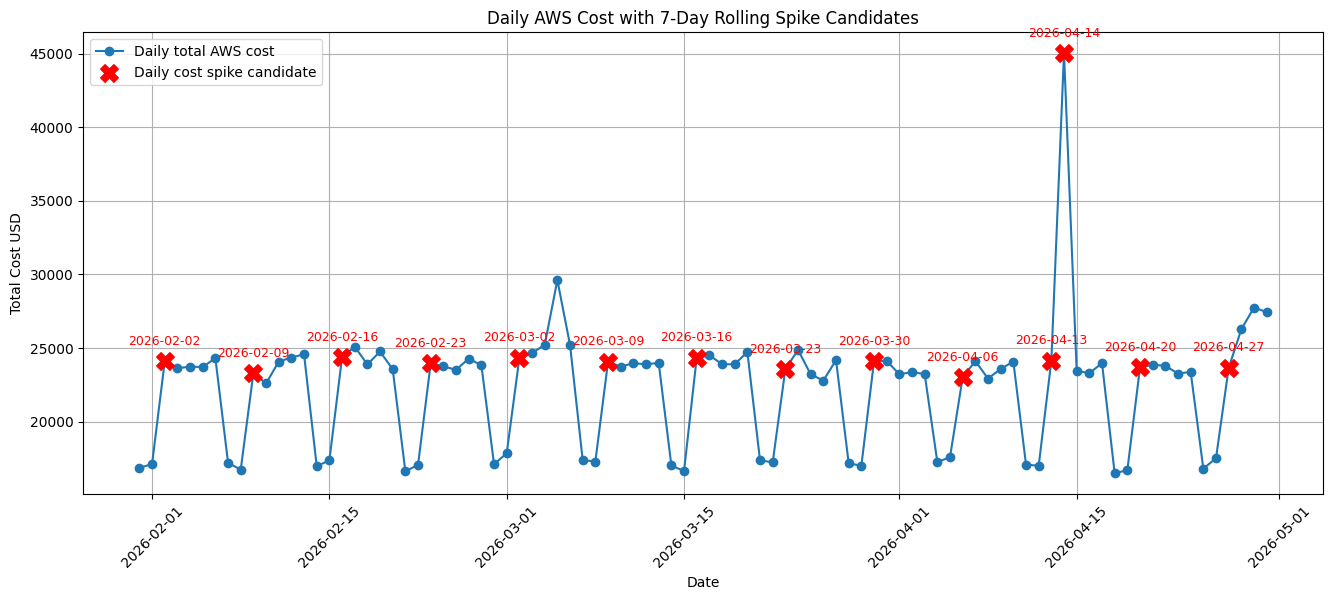

In [41]:
# ============================================================
# Visualize daily cost spike candidates
#
# Blue line:
# Daily AWS cost
#
# Red X markers:
# Candidate daily cost spikes based on 7-day rolling z-score
# and day-over-day cost increase.
# ============================================================

plt.figure(figsize=(16, 6))

plt.plot(
    daily_aws_df["date"],
    daily_aws_df["total_cost_usd"],
    marker="o",
    label="Daily total AWS cost"
)

plt.scatter(
    daily_cost_spike_candidates["date"],
    daily_cost_spike_candidates["total_cost_usd"],
    color="red",
    marker="X",
    s=160,
    label="Daily cost spike candidate",
    zorder=10
)

for _, row in daily_cost_spike_candidates.iterrows():
    plt.annotate(
        row["date"].strftime("%Y-%m-%d"),
        (row["date"], row["total_cost_usd"]),
        textcoords="offset points",
        xytext=(0, 12),
        ha="center",
        fontsize=9,
        color="red"
    )

plt.title("Daily AWS Cost with 7-Day Rolling Spike Candidates")
plt.xlabel("Date")
plt.ylabel("Total Cost USD")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

In [42]:
k8s_metrics_df.head()

,timestamp,pod_name,namespace,node,cpu_usage_cores,memory_usage_mb,cpu_request_cores,memory_request_mb,date
0,2026-01-31,api-gateway-7f8d9,production,node-01,0.13,199.10,0.50,512,2026-01-31
1,2026-01-31,batch-processor-1d5f3,production,node-01,0.38,976.10,1.00,2048,2026-01-31
2,2026-01-31,cache-layer-5f1d9,production,node-01,0.24,484.10,0.50,1024,2026-01-31
3,2026-01-31,data-pipeline-4a2c1,production,node-02,0.78,"1,912.10",2.00,4096,2026-01-31
4,2026-01-31,legacy-etl-2e7b4,production,node-03,0.05,86.20,2.00,4096,2026-01-31


## Kubernetes utilization features

In [43]:
# ============================================================
# Create Kubernetes utilization features
#
# Purpose:
# Convert raw Kubernetes metrics into utilization ratios.
#
# Why:
# Cost anomalies may be workload-driven. CPU and memory usage
# help explain whether cost spikes align with infrastructure load.
# ============================================================

k8s_metrics_df["cpu_utilization_ratio"] = (
    k8s_metrics_df["cpu_usage_cores"] /
    k8s_metrics_df["cpu_request_cores"]
)

k8s_metrics_df["memory_utilization_ratio"] = (
    k8s_metrics_df["memory_usage_mb"] /
    k8s_metrics_df["memory_request_mb"]
)

k8s_metrics_df = k8s_metrics_df.replace([np.inf, -np.inf], np.nan)

display(
    k8s_metrics_df[
        [
            "timestamp",
            "date",
            "pod_name",
            "cpu_usage_cores",
            "cpu_request_cores",
            "cpu_utilization_ratio",
            "memory_usage_mb",
            "memory_request_mb",
            "memory_utilization_ratio"
        ]
    ].head()
)

,timestamp,date,pod_name,cpu_usage_cores,cpu_request_cores,cpu_utilization_ratio,memory_usage_mb,memory_request_mb,memory_utilization_ratio
0,2026-01-31,2026-01-31,api-gateway-7f8d9,0.13,0.50,0.27,199.10,512,0.39
1,2026-01-31,2026-01-31,batch-processor-1d5f3,0.38,1.00,0.38,976.10,2048,0.48
2,2026-01-31,2026-01-31,cache-layer-5f1d9,0.24,0.50,0.47,484.10,1024,0.47
3,2026-01-31,2026-01-31,data-pipeline-4a2c1,0.78,2.00,0.39,"1,912.10",4096,0.47
4,2026-01-31,2026-01-31,legacy-etl-2e7b4,0.05,2.00,0.02,86.20,4096,0.02


## Daily Kubernetes aggregation

In [44]:
# ============================================================
# Aggregate Kubernetes metrics at pod-day level
#
# Purpose:
# Preserve workload-specific pod behaviour before summarizing
# Kubernetes metrics at daily level.
#
# Granularity:
# One row = one pod on one day
# ============================================================

daily_pod_k8s_df = (
    k8s_metrics_df
    .groupby(["date", "pod_name"], as_index=False)
    .agg(
        pod_avg_cpu_usage_cores=("cpu_usage_cores", "mean"),
        pod_max_cpu_usage_cores=("cpu_usage_cores", "max"),
        pod_avg_memory_usage_mb=("memory_usage_mb", "mean"),
        pod_max_memory_usage_mb=("memory_usage_mb", "max"),
        pod_avg_cpu_utilization_ratio=("cpu_utilization_ratio", "mean"),
        pod_max_cpu_utilization_ratio=("cpu_utilization_ratio", "max"),
        pod_avg_memory_utilization_ratio=("memory_utilization_ratio", "mean"),
        pod_max_memory_utilization_ratio=("memory_utilization_ratio", "max")
    )
    .sort_values(["date", "pod_name"])
)

display(daily_pod_k8s_df.head())
display(daily_pod_k8s_df.tail())

,date,pod_name,pod_avg_cpu_usage_cores,pod_max_cpu_usage_cores,pod_avg_memory_usage_mb,pod_max_memory_usage_mb,pod_avg_cpu_utilization_ratio,pod_max_cpu_utilization_ratio,pod_avg_memory_utilization_ratio,pod_max_memory_utilization_ratio
0,2026-01-31,api-gateway-7f8d9,0.14,0.20,216.45,263.00,0.27,0.40,0.42,0.51
1,2026-01-31,batch-processor-1d5f3,0.40,0.58,981.79,"1,270.80",0.40,0.58,0.48,0.62
2,2026-01-31,cache-layer-5f1d9,0.25,0.36,559.85,663.90,0.50,0.72,0.55,0.65
3,2026-01-31,data-pipeline-4a2c1,0.81,1.22,"1,963.39","2,353.70",0.41,0.61,0.48,0.57
4,2026-01-31,legacy-etl-2e7b4,0.06,0.09,85.57,108.90,0.03,0.05,0.02,0.03


,date,pod_name,pod_avg_cpu_usage_cores,pod_max_cpu_usage_cores,pod_avg_memory_usage_mb,pod_max_memory_usage_mb,pod_avg_cpu_utilization_ratio,pod_max_cpu_utilization_ratio,pod_avg_memory_utilization_ratio,pod_max_memory_utilization_ratio
625,2026-04-30,cache-layer-5f1d9,0.33,0.63,773.72,"1,118.10",0.66,1.25,0.76,1.09
626,2026-04-30,data-pipeline-4a2c1,1.13,1.82,"4,011.09","5,793.50",0.57,0.91,0.98,1.41
627,2026-04-30,legacy-etl-2e7b4,0.08,0.12,116.89,164.20,0.04,0.06,0.03,0.04
628,2026-04-30,model-serving-9b3e7,2.50,3.97,"5,130.93","7,430.70",0.62,0.99,0.63,0.91
629,2026-04-30,monitoring-agent-6c8a2,0.14,0.21,179.17,276.80,0.57,0.84,0.70,1.08


## Daily Kubernetes feature aggregation

In [46]:
# ============================================================
# Summarize pod-day Kubernetes metrics into daily features
#
# Purpose:
# Create daily workload features that can be joined with daily
# AWS cost data.
#
# Granularity:
# One row = one day
#
# Design:
# We use average, maximum, and standard deviation across pods.
# Standard deviation helps capture workload imbalance between pods.
# ============================================================

daily_k8s_df = (
    daily_pod_k8s_df
    .groupby("date", as_index=False)
    .agg(
        avg_cpu_usage_cores=("pod_avg_cpu_usage_cores", "mean"),
        max_cpu_usage_cores=("pod_max_cpu_usage_cores", "max"),
        cpu_usage_std=("pod_avg_cpu_usage_cores", "std"),

        avg_memory_usage_mb=("pod_avg_memory_usage_mb", "mean"),
        max_memory_usage_mb=("pod_max_memory_usage_mb", "max"),
        memory_usage_std=("pod_avg_memory_usage_mb", "std"),

        avg_cpu_utilization_ratio=("pod_avg_cpu_utilization_ratio", "mean"),
        max_cpu_utilization_ratio=("pod_max_cpu_utilization_ratio", "max"),

        avg_memory_utilization_ratio=("pod_avg_memory_utilization_ratio", "mean"),
        max_memory_utilization_ratio=("pod_max_memory_utilization_ratio", "max")
    )
    .sort_values("date")
)

daily_k8s_df = daily_k8s_df.fillna(0)

display(pd.concat([daily_k8s_df.head(), daily_k8s_df.tail()]))

,date,avg_cpu_usage_cores,max_cpu_usage_cores,cpu_usage_std,avg_memory_usage_mb,max_memory_usage_mb,memory_usage_std,avg_cpu_utilization_ratio,max_cpu_utilization_ratio,avg_memory_utilization_ratio,max_memory_utilization_ratio
0,2026-01-31,0.51,2.93,0.63,"1,063.38","4,279.80","1,264.97",0.36,0.73,0.41,0.66
1,2026-02-01,0.47,2.39,0.57,"1,062.49","4,744.00","1,270.42",0.33,0.68,0.41,0.73
2,2026-02-02,0.69,3.72,0.83,"1,514.90","7,818.40","1,839.26",0.49,1.15,0.57,1.25
3,2026-02-03,0.72,4.52,0.89,"1,507.49","7,465.20","1,811.58",0.49,1.13,0.57,1.14
4,2026-02-04,0.68,3.66,0.83,"1,503.40","7,173.20","1,815.27",0.48,1.10,0.57,1.14
85,2026-04-26,0.51,2.25,0.60,"1,160.00","4,123.70","1,354.22",0.37,0.72,0.44,0.77
86,2026-04-27,0.74,3.81,0.85,"1,654.02","7,232.10","1,947.78",0.53,1.07,0.62,1.34
87,2026-04-28,0.72,4.01,0.82,"1,667.35","7,665.80","1,982.88",0.53,1.01,0.62,1.42
88,2026-04-29,0.73,4.14,0.85,"1,674.21","7,549.10","1,974.41",0.53,1.10,0.63,1.39
89,2026-04-30,0.72,3.97,0.86,"1,705.08","7,430.70","2,027.47",0.52,1.25,0.64,1.41


## Topology check

In [48]:
# ============================================================
# Optional Kubernetes topology check
#
# Purpose:
# Check whether the number of active pods or active nodes changes
# over time.
#
# Note:
# If these values are constant, they should not be used as model
# features because they do not provide discriminatory information.
# ============================================================

daily_topology_df = (
    k8s_metrics_df
    .groupby("date", as_index=False)
    .agg(
        active_pods=("pod_name", "nunique"),
        active_nodes=("node", "nunique")
    )
)

display(daily_topology_df.head())

print("active_pods unique values:", daily_topology_df["active_pods"].unique())
print("active_nodes unique values:", daily_topology_df["active_nodes"].unique())

,date,active_pods,active_nodes
0,2026-01-31,7,3
1,2026-02-01,7,3
2,2026-02-02,7,3
3,2026-02-03,7,3
4,2026-02-04,7,3


active_pods unique values: [7]
active_nodes unique values: [3]


## Merge AWS and Kubernetes features

In [49]:
# ============================================================
# Merge daily AWS cost features with daily Kubernetes features
#
# Purpose:
# Build the final daily modelling dataset for Isolation Forest.
#
# Granularity:
# One row = one day
# ============================================================

daily_ml_df = daily_aws_df.merge(
    daily_k8s_df,
    on="date",
    how="left"
)

daily_ml_df = daily_ml_df.fillna(0)

print("Final ML dataset shape:", daily_ml_df.shape)

display(daily_ml_df.head())

Final ML dataset shape: (90, 25)


,date,total_cost_usd,mean_cost_usd,max_cost_usd,total_usage_quantity,mean_usage_quantity,unique_accounts,unique_services,unique_regions,unique_usage_types,cost_diff_abs,cost_diff_pct,rolling_mean_7d,rolling_std_7d,cost_z_score_7d,avg_cpu_usage_cores,max_cpu_usage_cores,cpu_usage_std,avg_memory_usage_mb,max_memory_usage_mb,memory_usage_std,avg_cpu_utilization_ratio,max_cpu_utilization_ratio,avg_memory_utilization_ratio,max_memory_utilization_ratio
0,2026-01-31,"16,862.60",187.36,"1,025.91","133,458,592.40","1,482,873.25",8,6,4,6,0.00,0.00,0.00,0.00,0.00,0.51,2.93,0.63,"1,063.38","4,279.80","1,264.97",0.36,0.73,0.41,0.66
1,2026-02-01,"17,107.44",190.08,"1,002.68","133,314,383.86","1,481,270.93",8,6,4,6,244.84,0.01,0.00,0.00,0.00,0.47,2.39,0.57,"1,062.49","4,744.00","1,270.42",0.33,0.68,0.41,0.73
2,2026-02-02,"24,095.45",267.73,"1,612.40","211,286,400.58","2,347,626.67",8,6,4,6,"6,988.01",0.41,"19,355.16","4,107.03",1.15,0.69,3.72,0.83,"1,514.90","7,818.40","1,839.26",0.49,1.15,0.57,1.25
3,2026-02-03,"23,620.45",262.45,"1,777.13","201,351,235.12","2,237,235.95",8,6,4,6,-475.00,-0.02,"20,421.49","3,974.08",0.80,0.72,4.52,0.89,"1,507.49","7,465.20","1,811.58",0.49,1.13,0.57,1.14
4,2026-02-04,"23,736.00",263.73,"1,638.11","209,291,301.51","2,325,458.91",8,6,4,6,115.55,0.00,"21,084.39","3,747.29",0.71,0.68,3.66,0.83,"1,503.40","7,173.20","1,815.27",0.48,1.10,0.57,1.14


## Correlation analysis

In [50]:
# ============================================================
# Correlation analysis
#
# Purpose:
# Understand relationships between cost, usage, and Kubernetes
# workload features before model training.
# ============================================================

correlation_cols = [
    "total_cost_usd",
    "total_usage_quantity",
    "avg_cpu_usage_cores",
    "max_cpu_usage_cores",
    "cpu_usage_std",
    "avg_memory_usage_mb",
    "max_memory_usage_mb",
    "memory_usage_std",
    "avg_cpu_utilization_ratio",
    "avg_memory_utilization_ratio"
]

correlation_matrix = daily_ml_df[correlation_cols].corr()

print("Correlation with total_cost_usd:")
display(
    correlation_matrix["total_cost_usd"]
    .sort_values(ascending=False)
)

display(correlation_matrix)

Correlation with total_cost_usd:


total_cost_usd                 1.00
memory_usage_std               0.97
avg_cpu_usage_cores            0.95
max_memory_usage_mb            0.95
avg_cpu_utilization_ratio      0.93
avg_memory_usage_mb            0.93
max_cpu_usage_cores            0.88
avg_memory_utilization_ratio   0.87
cpu_usage_std                  0.85
total_usage_quantity           0.81
Name: total_cost_usd, dtype: float64

,total_cost_usd,total_usage_quantity,avg_cpu_usage_cores,max_cpu_usage_cores,cpu_usage_std,avg_memory_usage_mb,max_memory_usage_mb,memory_usage_std,avg_cpu_utilization_ratio,avg_memory_utilization_ratio
total_cost_usd,1.00,0.81,0.95,0.88,0.85,0.93,0.95,0.97,0.93,0.87
total_usage_quantity,0.81,1.00,0.69,0.53,0.45,0.92,0.84,0.81,0.90,0.96
avg_cpu_usage_cores,0.95,0.69,1.00,0.96,0.95,0.89,0.95,0.97,0.91,0.79
max_cpu_usage_cores,0.88,0.53,0.96,1.00,0.98,0.76,0.87,0.90,0.78,0.63
cpu_usage_std,0.85,0.45,0.95,0.98,1.00,0.71,0.82,0.86,0.73,0.56
avg_memory_usage_mb,0.93,0.92,0.89,0.76,0.71,1.00,0.95,0.97,0.98,0.98
max_memory_usage_mb,0.95,0.84,0.95,0.87,0.82,0.95,1.00,0.97,0.96,0.90
memory_usage_std,0.97,0.81,0.97,0.90,0.86,0.97,0.97,1.00,0.95,0.89
avg_cpu_utilization_ratio,0.93,0.90,0.91,0.78,0.73,0.98,0.96,0.95,1.00,0.96
avg_memory_utilization_ratio,0.87,0.96,0.79,0.63,0.56,0.98,0.90,0.89,0.96,1.00


## Plot cost vs CPU

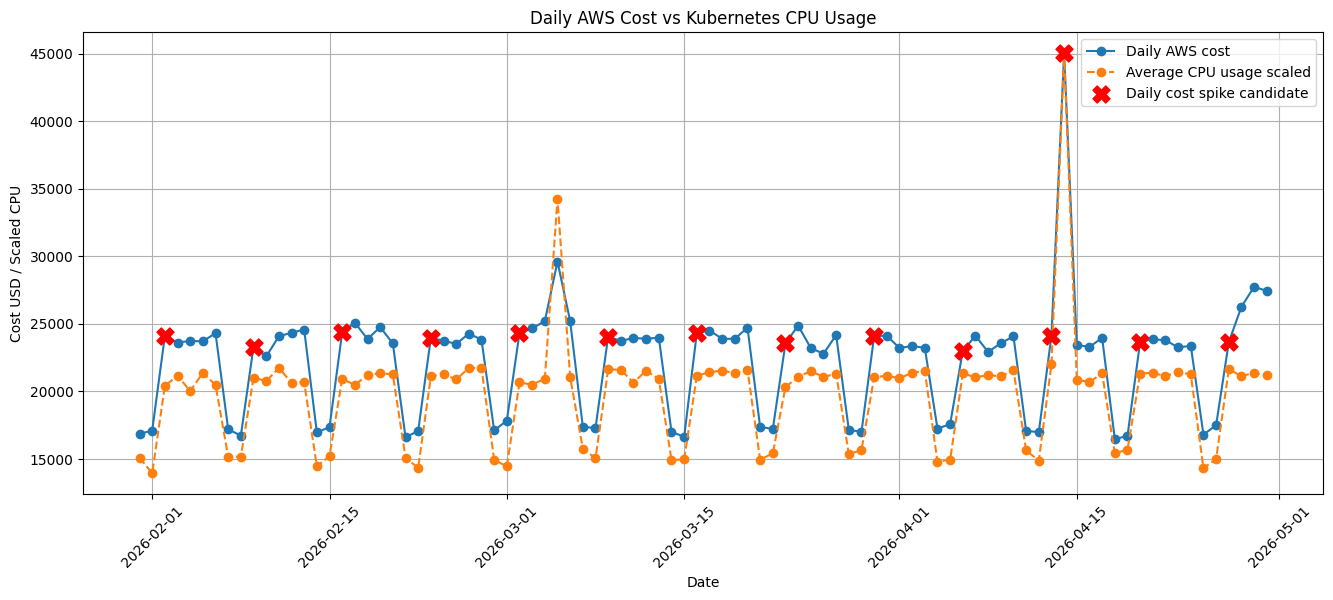

In [51]:
# ============================================================
# Visualize AWS cost and Kubernetes CPU relationship
#
# Purpose:
# Show whether cost spikes align with Kubernetes workload.
#
# Note:
# CPU is scaled only for visualization.
# ============================================================

cpu_scale_factor = (
    daily_ml_df["total_cost_usd"].max() /
    daily_ml_df["avg_cpu_usage_cores"].max()
)

plt.figure(figsize=(16, 6))

plt.plot(
    daily_ml_df["date"],
    daily_ml_df["total_cost_usd"],
    marker="o",
    label="Daily AWS cost"
)

plt.plot(
    daily_ml_df["date"],
    daily_ml_df["avg_cpu_usage_cores"] * cpu_scale_factor,
    marker="o",
    linestyle="--",
    label="Average CPU usage scaled"
)

plt.scatter(
    daily_cost_spike_candidates["date"],
    daily_cost_spike_candidates["total_cost_usd"],
    color="red",
    marker="X",
    s=150,
    label="Daily cost spike candidate",
    zorder=10
)

plt.title("Daily AWS Cost vs Kubernetes CPU Usage")
plt.xlabel("Date")
plt.ylabel("Cost USD / Scaled CPU")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

## Define Isolation Forest features

In [52]:
# ============================================================
# Define Isolation Forest input features
#
# Purpose:
# Select daily cost, usage, rolling cost deviation, and
# Kubernetes workload features.
#
# Note:
# active_pods and active_nodes are excluded because they are
# constant in this dataset.
# ============================================================

feature_cols = [
    "total_cost_usd",
    "mean_cost_usd",
    "max_cost_usd",

    "total_usage_quantity",
    "mean_usage_quantity",

    "cost_diff_abs",
    "cost_diff_pct",
    "cost_z_score_7d",

    "avg_cpu_usage_cores",
    "max_cpu_usage_cores",
    "cpu_usage_std",

    "avg_memory_usage_mb",
    "max_memory_usage_mb",
    "memory_usage_std",

    "avg_cpu_utilization_ratio",
    "avg_memory_utilization_ratio"
]

X = daily_ml_df[feature_cols].copy()

print("Number of features:", len(feature_cols))
display(X.head())

Number of features: 16


,total_cost_usd,mean_cost_usd,max_cost_usd,total_usage_quantity,mean_usage_quantity,cost_diff_abs,cost_diff_pct,cost_z_score_7d,avg_cpu_usage_cores,max_cpu_usage_cores,cpu_usage_std,avg_memory_usage_mb,max_memory_usage_mb,memory_usage_std,avg_cpu_utilization_ratio,avg_memory_utilization_ratio
0,"16,862.60",187.36,"1,025.91","133,458,592.40","1,482,873.25",0.00,0.00,0.00,0.51,2.93,0.63,"1,063.38","4,279.80","1,264.97",0.36,0.41
1,"17,107.44",190.08,"1,002.68","133,314,383.86","1,481,270.93",244.84,0.01,0.00,0.47,2.39,0.57,"1,062.49","4,744.00","1,270.42",0.33,0.41
2,"24,095.45",267.73,"1,612.40","211,286,400.58","2,347,626.67","6,988.01",0.41,1.15,0.69,3.72,0.83,"1,514.90","7,818.40","1,839.26",0.49,0.57
3,"23,620.45",262.45,"1,777.13","201,351,235.12","2,237,235.95",-475.00,-0.02,0.80,0.72,4.52,0.89,"1,507.49","7,465.20","1,811.58",0.49,0.57
4,"23,736.00",263.73,"1,638.11","209,291,301.51","2,325,458.91",115.55,0.00,0.71,0.68,3.66,0.83,"1,503.40","7,173.20","1,815.27",0.48,0.57


## Hyperparameter stability analysis

In [53]:
%%time

# ============================================================
# Hyperparameter stability analysis for Isolation Forest
#
# Purpose:
# Since labelled anomalies are not available, we cannot use
# traditional GridSearchCV with a supervised scoring metric.
#
# Instead, we run Isolation Forest with multiple reasonable
# hyperparameter combinations and check which dates are detected
# consistently.
#
# Interpretation:
# A date detected by many model configurations is considered
# a more stable and reliable anomaly candidate.
# ============================================================

param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "contamination": [0.01, 0.02, 0.03, 0.04, 0.05]
}

stability_rows = []

for n_estimators in param_grid["n_estimators"]:
    
    for contamination in param_grid["contamination"]:
        
        model = Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                ("isolation_forest", IsolationForest(
                    n_estimators=n_estimators,
                    contamination=contamination,
                    random_state=42
                ))
            ]
        )
        
        model.fit(X)
        
        labels = model.predict(X)
        scores = model.decision_function(X)
        
        temp_result_df = daily_ml_df[["date", "total_cost_usd"]].copy()
        temp_result_df["n_estimators"] = n_estimators
        temp_result_df["contamination"] = contamination
        temp_result_df["ml_anomaly_label"] = labels
        temp_result_df["ml_anomaly_score"] = scores
        
        detected_df = temp_result_df[
            temp_result_df["ml_anomaly_label"] == -1
        ].copy()
        
        stability_rows.append(detected_df)

stability_detection_df = pd.concat(
    stability_rows,
    ignore_index=True
)

display(stability_detection_df.head())
print("Total detected anomaly rows across all model runs:", stability_detection_df.shape[0])

,date,total_cost_usd,n_estimators,contamination,ml_anomaly_label,ml_anomaly_score
0,2026-04-14,"45,023.11",100,0.01,-1,-0.07
1,2026-03-05,"29,610.55",100,0.02,-1,-0.14
2,2026-04-14,"45,023.11",100,0.02,-1,-0.22
3,2026-03-05,"29,610.55",100,0.03,-1,-0.19
4,2026-04-14,"45,023.11",100,0.03,-1,-0.27


Total detected anomaly rows across all model runs: 60
CPU times: user 3.06 s, sys: 74.1 ms, total: 3.14 s
Wall time: 3.14 s


## Build consensus anomaly table

In [54]:
# ============================================================
# Build consensus anomaly table
#
# Purpose:
# Count how many hyperparameter configurations detected each date
# as an anomaly.
#
# Metrics:
# - detection_count: number of model configurations that detected the date
# - avg_anomaly_score: average Isolation Forest score across detections
# - min_anomaly_score: strongest anomaly score observed
#
# Lower anomaly score means more anomalous.
# ============================================================

total_model_runs = (
    len(param_grid["n_estimators"]) *
    len(param_grid["contamination"])
)

consensus_anomaly_df = (
    stability_detection_df
    .groupby("date", as_index=False)
    .agg(
        detection_count=("ml_anomaly_label", "count"),
        avg_anomaly_score=("ml_anomaly_score", "mean"),
        min_anomaly_score=("ml_anomaly_score", "min"),
        avg_total_cost_usd=("total_cost_usd", "mean")
    )
)

consensus_anomaly_df["detection_rate"] = (
    consensus_anomaly_df["detection_count"] / total_model_runs
)

consensus_anomaly_df = consensus_anomaly_df.sort_values(
    ["detection_count", "avg_total_cost_usd"],
    ascending=[False, False]
)

display(consensus_anomaly_df)

,date,detection_count,avg_anomaly_score,min_anomaly_score,avg_total_cost_usd,detection_rate
2,2026-04-14,20,-0.23,-0.29,"45,023.11",1.00
1,2026-03-05,16,-0.18,-0.20,"29,610.55",0.80
3,2026-04-25,12,-0.02,-0.02,"16,800.20",0.60
7,2026-04-30,8,-0.00,-0.01,"27,440.17",0.40
6,2026-04-29,1,-0.00,-0.00,"27,743.61",0.05
5,2026-04-28,1,-0.00,-0.00,"26,272.61",0.05
4,2026-04-26,1,-0.00,-0.00,"17,512.82",0.05
0,2026-02-01,1,-0.00,-0.00,"17,107.44",0.05


## Join consensus with cost features

In [55]:
# ============================================================
# Join consensus results with daily cost features
#
# Purpose:
# Add cost movement and rolling z-score metrics to the consensus
# anomaly table so that we can select cost-relevant anomalies.
# ============================================================

consensus_with_cost_df = consensus_anomaly_df.merge(
    daily_ml_df[
        [
            "date",
            "total_cost_usd",
            "cost_diff_abs",
            "cost_diff_pct",
            "cost_z_score_7d",
            "avg_cpu_usage_cores",
            "avg_memory_usage_mb"
        ]
    ],
    on="date",
    how="left"
)

display(
    consensus_with_cost_df[
        [
            "date",
            "detection_count",
            "detection_rate",
            "total_cost_usd",
            "cost_diff_abs",
            "cost_diff_pct",
            "cost_z_score_7d",
            "avg_cpu_usage_cores",
            "avg_memory_usage_mb",
            "avg_anomaly_score",
            "min_anomaly_score"
        ]
    ]
)

,date,detection_count,detection_rate,total_cost_usd,cost_diff_abs,cost_diff_pct,cost_z_score_7d,avg_cpu_usage_cores,avg_memory_usage_mb,avg_anomaly_score,min_anomaly_score
0,2026-04-14,20,1.00,"45,023.11","20,894.66",0.87,2.14,1.53,"2,064.70",-0.23,-0.29
1,2026-03-05,16,0.80,"29,610.55","4,404.87",0.17,1.46,1.16,"1,881.18",-0.18,-0.20
2,2026-04-25,12,0.60,"16,800.20","-6,577.05",-0.28,-1.45,0.49,"1,178.49",-0.02,-0.02
3,2026-04-30,8,0.40,"27,440.17",-303.44,-0.01,0.93,0.72,"1,705.08",-0.00,-0.01
4,2026-04-29,1,0.05,"27,743.61","1,471.00",0.06,1.24,0.73,"1,674.21",-0.00,-0.00
5,2026-04-28,1,0.05,"26,272.61","2,631.93",0.11,1.18,0.72,"1,667.35",-0.00,-0.00
6,2026-04-26,1,0.05,"17,512.82",712.62,0.04,-1.34,0.51,"1,160.00",-0.00,-0.00
7,2026-02-01,1,0.05,"17,107.44",244.84,0.01,0.00,0.47,"1,062.49",-0.00,-0.00


## Select final top 3 cost anomalies

In [56]:
# ============================================================
# Select final top 3 cost anomalies
#
# Purpose:
# Select the most stable anomalies that are also cost-relevant.
#
# Cost relevance criteria:
# - Positive day-over-day cost increase
# - OR total cost above the 75th percentile
#
# Final ranking:
# 1. Higher detection count
# 2. Higher total cost
# 3. Lower average anomaly score
# ============================================================

cost_threshold_75p = daily_ml_df["total_cost_usd"].quantile(0.75)

cost_relevant_consensus_df = (
    consensus_with_cost_df[
        (consensus_with_cost_df["cost_diff_abs"] > 0) |
        (consensus_with_cost_df["total_cost_usd"] >= cost_threshold_75p)
    ]
    .sort_values(
        ["detection_count", "total_cost_usd", "avg_anomaly_score"],
        ascending=[False, False, True]
    )
)

top_3_cost_anomalies_df = (
    cost_relevant_consensus_df
    .head(3)
    .copy()
)

display(
    top_3_cost_anomalies_df[
        [
            "date",
            "detection_count",
            "detection_rate",
            "total_cost_usd",
            "cost_diff_abs",
            "cost_diff_pct",
            "cost_z_score_7d",
            "avg_cpu_usage_cores",
            "avg_memory_usage_mb",
            "avg_anomaly_score",
            "min_anomaly_score"
        ]
    ]
)

,date,detection_count,detection_rate,total_cost_usd,cost_diff_abs,cost_diff_pct,cost_z_score_7d,avg_cpu_usage_cores,avg_memory_usage_mb,avg_anomaly_score,min_anomaly_score
0,2026-04-14,20,1.00,"45,023.11","20,894.66",0.87,2.14,1.53,"2,064.70",-0.23,-0.29
1,2026-03-05,16,0.80,"29,610.55","4,404.87",0.17,1.46,1.16,"1,881.18",-0.18,-0.20
3,2026-04-30,8,0.40,"27,440.17",-303.44,-0.01,0.93,0.72,"1,705.08",-0.00,-0.01


## Plot consensus anomaly stability

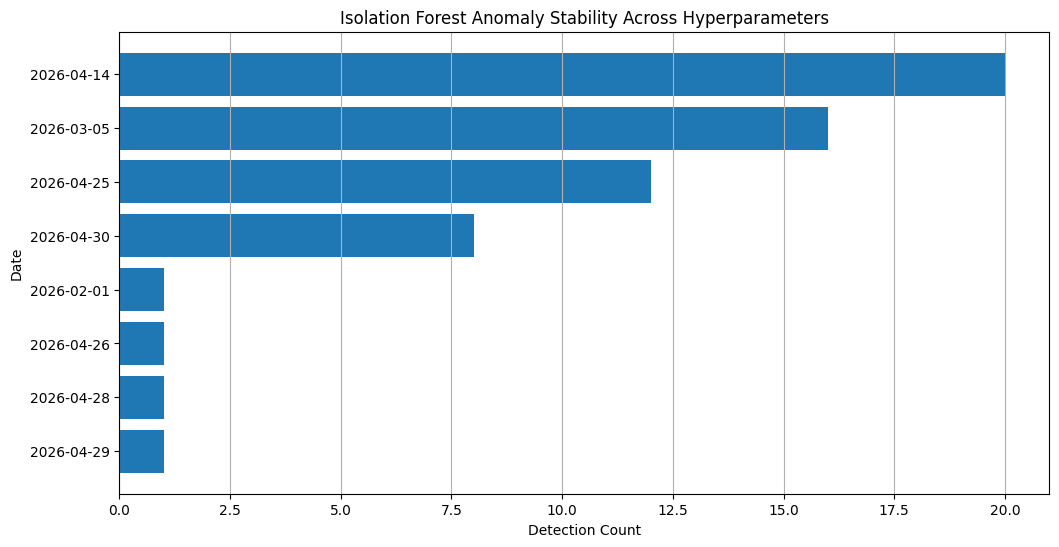

In [57]:
# ============================================================
# Plot anomaly detection stability
#
# Purpose:
# Show which dates were most consistently detected across
# multiple Isolation Forest hyperparameter configurations.
# ============================================================

plot_df = consensus_with_cost_df.sort_values(
    "detection_count",
    ascending=True
)

plt.figure(figsize=(12, 6))

plt.barh(
    plot_df["date"].dt.strftime("%Y-%m-%d"),
    plot_df["detection_count"]
)

plt.title("Isolation Forest Anomaly Stability Across Hyperparameters")
plt.xlabel("Detection Count")
plt.ylabel("Date")
plt.grid(axis="x")

plt.show()

In [58]:
## Plot final top 3 anomalies

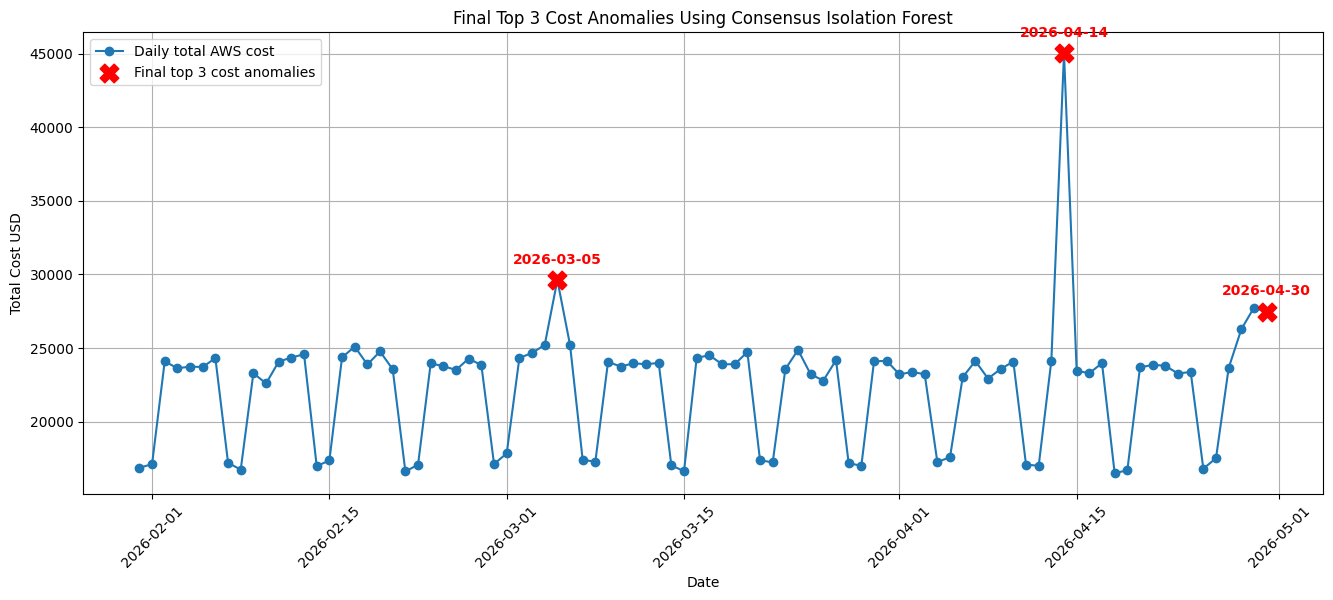

In [59]:
# ============================================================
# Visualize final top 3 cost anomalies
#
# Purpose:
# Present the selected cost-relevant anomaly candidates on the
# daily AWS cost time series.
# ============================================================

plt.figure(figsize=(16, 6))

plt.plot(
    daily_ml_df["date"],
    daily_ml_df["total_cost_usd"],
    marker="o",
    label="Daily total AWS cost"
)

plt.scatter(
    top_3_cost_anomalies_df["date"],
    top_3_cost_anomalies_df["total_cost_usd"],
    color="red",
    marker="X",
    s=180,
    label="Final top 3 cost anomalies",
    zorder=10
)

for _, row in top_3_cost_anomalies_df.iterrows():
    plt.annotate(
        row["date"].strftime("%Y-%m-%d"),
        (row["date"], row["total_cost_usd"]),
        textcoords="offset points",
        xytext=(0, 12),
        ha="center",
        fontsize=10,
        color="red",
        fontweight="bold"
    )

plt.title("Final Top 3 Cost Anomalies Using Consensus Isolation Forest")
plt.xlabel("Date")
plt.ylabel("Total Cost USD")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.show()

## Root cause analysis

In [60]:
# ============================================================
# Root cause analysis for final anomalies
#
# Purpose:
# Drill down into AWS CUR dimensions to identify the largest
# cost contributor for each selected anomaly date.
# ============================================================

root_cause_tables = {}

for anomaly_date in top_3_cost_anomalies_df["date"]:
    
    print("=" * 100)
    print("Anomaly date:", anomaly_date.date())
    
    root_cause_df = (
        aws_cur_df[aws_cur_df["date"] == anomaly_date]
        .groupby(
            ["account_id", "service", "usage_type", "region"],
            as_index=False
        )
        .agg(
            root_cause_cost_usd=("cost_usd", "sum"),
            root_cause_usage_quantity=("usage_quantity", "sum")
        )
        .sort_values("root_cause_cost_usd", ascending=False)
    )
    
    root_cause_df["cost_share_pct"] = (
        root_cause_df["root_cause_cost_usd"] /
        root_cause_df["root_cause_cost_usd"].sum()
    ) * 100
    
    root_cause_tables[anomaly_date] = root_cause_df
    
    display(root_cause_df.head(10))

Anomaly date: 2026-04-14


,account_id,service,usage_type,region,root_cause_cost_usd,root_cause_usage_quantity,cost_share_pct
5,acct_001,AmazonEC2,BoxUsage:m5.xlarge,us-east-1,"12,612.81","65,691.57",28.01
4,acct_001,AmazonEC2,BoxUsage:m5.xlarge,eu-west-1,"11,950.07","62,239.98",26.54
14,acct_002,AmazonEC2,BoxUsage:m5.xlarge,us-west-2,"1,698.60","8,846.89",3.77
47,acct_005,AmazonEC2,BoxUsage:m5.xlarge,us-west-2,"1,176.60","6,128.14",2.61
46,acct_005,AmazonEC2,BoxUsage:m5.xlarge,us-east-1,970.90,"5,056.79",2.16
16,acct_002,AmazonRDS,InstanceUsage:db.r5.large,us-west-2,701.48,"2,922.84",1.56
8,acct_001,AmazonRDS,InstanceUsage:db.r5.large,eu-west-1,646.79,"2,694.97",1.44
9,acct_001,AmazonRDS,InstanceUsage:db.r5.large,us-east-1,631.27,"2,630.29",1.40
65,acct_007,AmazonEC2,BoxUsage:m5.xlarge,eu-west-1,594.85,"3,098.19",1.32
64,acct_007,AmazonEC2,BoxUsage:m5.xlarge,eu-central-1,532.71,"2,774.53",1.18


Anomaly date: 2026-03-05


,account_id,service,usage_type,region,root_cause_cost_usd,root_cause_usage_quantity,cost_share_pct
4,acct_001,AmazonEC2,BoxUsage:m5.xlarge,eu-west-1,"4,606.46","23,325.36",15.56
5,acct_001,AmazonEC2,BoxUsage:m5.xlarge,us-east-1,"3,421.82","17,557.58",11.56
14,acct_002,AmazonEC2,BoxUsage:m5.xlarge,us-west-2,"1,951.96","10,290.61",6.59
47,acct_005,AmazonEC2,BoxUsage:m5.xlarge,us-west-2,"1,068.93","5,531.51",3.61
46,acct_005,AmazonEC2,BoxUsage:m5.xlarge,us-east-1,937.65,"4,907.94",3.17
16,acct_002,AmazonRDS,InstanceUsage:db.r5.large,us-west-2,759.76,"3,213.98",2.57
78,acct_008,AmazonEC2,BoxUsage:m5.xlarge,eu-west-1,736.67,"3,810.50",2.49
9,acct_001,AmazonRDS,InstanceUsage:db.r5.large,us-east-1,718.14,"3,088.25",2.43
64,acct_007,AmazonEC2,BoxUsage:m5.xlarge,eu-central-1,670.83,"3,511.36",2.27
80,acct_008,AmazonEC2,BoxUsage:m5.xlarge,us-west-2,632.05,"3,315.32",2.13


Anomaly date: 2026-04-30


,account_id,service,usage_type,region,root_cause_cost_usd,root_cause_usage_quantity,cost_share_pct
14,acct_002,AmazonEC2,BoxUsage:m5.xlarge,us-west-2,"1,777.20","9,256.25",6.48
5,acct_001,AmazonEC2,BoxUsage:m5.xlarge,us-east-1,"1,686.28","8,782.70",6.15
47,acct_005,AmazonEC2,BoxUsage:m5.xlarge,us-west-2,"1,372.98","7,150.96",5.00
4,acct_001,AmazonEC2,BoxUsage:m5.xlarge,eu-west-1,"1,350.48","7,033.75",4.92
46,acct_005,AmazonEC2,BoxUsage:m5.xlarge,us-east-1,"1,296.77","6,754.01",4.73
16,acct_002,AmazonRDS,InstanceUsage:db.r5.large,us-west-2,866.09,"3,608.70",3.16
64,acct_007,AmazonEC2,BoxUsage:m5.xlarge,eu-central-1,784.33,"4,085.05",2.86
8,acct_001,AmazonRDS,InstanceUsage:db.r5.large,eu-west-1,779.61,"3,248.37",2.84
9,acct_001,AmazonRDS,InstanceUsage:db.r5.large,us-east-1,776.99,"3,237.44",2.83
80,acct_008,AmazonEC2,BoxUsage:m5.xlarge,us-west-2,708.90,"3,692.18",2.58


## Kubernetes context for final anomalies

In [61]:
# ============================================================
# Kubernetes context for final anomalies
#
# Purpose:
# Inspect pod-level Kubernetes workload metrics on each selected
# anomaly date.
# ============================================================

for anomaly_date in top_3_cost_anomalies_df["date"]:
    
    print("=" * 100)
    print("Kubernetes context for anomaly date:", anomaly_date.date())
    
    k8s_context_df = (
        daily_pod_k8s_df[daily_pod_k8s_df["date"] == anomaly_date]
        .sort_values("pod_max_cpu_usage_cores", ascending=False)
    )
    
    display(k8s_context_df.head(10))

Kubernetes context for anomaly date: 2026-04-14


,date,pod_name,pod_avg_cpu_usage_cores,pod_max_cpu_usage_cores,pod_avg_memory_usage_mb,pod_max_memory_usage_mb,pod_avg_cpu_utilization_ratio,pod_max_cpu_utilization_ratio,pod_avg_memory_utilization_ratio,pod_max_memory_utilization_ratio
516,2026-04-14,model-serving-9b3e7,8.10,12.76,"9,000.13","13,530.60",2.02,3.19,1.10,1.65
514,2026-04-14,data-pipeline-4a2c1,1.17,1.99,"2,641.63","3,946.50",0.59,0.99,0.64,0.96
512,2026-04-14,batch-processor-1d5f3,0.58,0.89,"1,384.81","2,057.60",0.58,0.89,0.68,1.00
513,2026-04-14,cache-layer-5f1d9,0.33,0.58,756.19,"1,107.00",0.66,1.16,0.74,1.08
511,2026-04-14,api-gateway-7f8d9,0.31,0.44,374.80,588.80,0.61,0.87,0.73,1.15
517,2026-04-14,monitoring-agent-6c8a2,0.15,0.22,179.07,269.30,0.59,0.88,0.70,1.05
515,2026-04-14,legacy-etl-2e7b4,0.08,0.14,116.28,167.90,0.04,0.07,0.03,0.04


Kubernetes context for anomaly date: 2026-03-05


,date,pod_name,pod_avg_cpu_usage_cores,pod_max_cpu_usage_cores,pod_avg_memory_usage_mb,pod_max_memory_usage_mb,pod_avg_cpu_utilization_ratio,pod_max_cpu_utilization_ratio,pod_avg_memory_utilization_ratio,pod_max_memory_utilization_ratio
236,2026-03-05,model-serving-9b3e7,5.56,9.24,"7,735.65","11,794.20",1.39,2.31,0.94,1.44
234,2026-03-05,data-pipeline-4a2c1,1.20,1.86,"2,678.50","4,109.70",0.60,0.93,0.65,1.00
232,2026-03-05,batch-processor-1d5f3,0.59,0.91,"1,392.70","1,967.10",0.59,0.91,0.68,0.96
233,2026-03-05,cache-layer-5f1d9,0.35,0.54,732.90,"1,038.10",0.69,1.08,0.72,1.01
231,2026-03-05,api-gateway-7f8d9,0.24,0.37,338.96,482.00,0.47,0.74,0.66,0.94
237,2026-03-05,monitoring-agent-6c8a2,0.15,0.21,174.42,254.10,0.58,0.84,0.68,0.99
235,2026-03-05,legacy-etl-2e7b4,0.08,0.12,115.12,164.20,0.04,0.06,0.03,0.04


Kubernetes context for anomaly date: 2026-04-30


,date,pod_name,pod_avg_cpu_usage_cores,pod_max_cpu_usage_cores,pod_avg_memory_usage_mb,pod_max_memory_usage_mb,pod_avg_cpu_utilization_ratio,pod_max_cpu_utilization_ratio,pod_avg_memory_utilization_ratio,pod_max_memory_utilization_ratio
628,2026-04-30,model-serving-9b3e7,2.50,3.97,"5,130.93","7,430.70",0.62,0.99,0.63,0.91
626,2026-04-30,data-pipeline-4a2c1,1.13,1.82,"4,011.09","5,793.50",0.57,0.91,0.98,1.41
624,2026-04-30,batch-processor-1d5f3,0.58,0.92,"1,346.46","1,977.60",0.58,0.92,0.66,0.97
625,2026-04-30,cache-layer-5f1d9,0.33,0.63,773.72,"1,118.10",0.66,1.25,0.76,1.09
623,2026-04-30,api-gateway-7f8d9,0.29,0.45,377.31,543.10,0.58,0.91,0.74,1.06
629,2026-04-30,monitoring-agent-6c8a2,0.14,0.21,179.17,276.80,0.57,0.84,0.70,1.08
627,2026-04-30,legacy-etl-2e7b4,0.08,0.12,116.89,164.20,0.04,0.06,0.03,0.04


## Create final report

In [62]:
# ============================================================
# Create final anomaly report
#
# Purpose:
# Create one clean output table for Question 1.
# ============================================================

final_rows = []

for anomaly_rank, anomaly_row in enumerate(top_3_cost_anomalies_df.itertuples(), start=1):
    
    anomaly_date = anomaly_row.date
    
    daily_info = (
        daily_ml_df[daily_ml_df["date"] == anomaly_date]
        .iloc[0]
    )
    
    root_cause_df = root_cause_tables[anomaly_date]
    main_root_cause = root_cause_df.iloc[0]
    
    final_rows.append({
        "anomaly_rank": anomaly_rank,
        "date": anomaly_date.strftime("%Y-%m-%d"),
        "detection_method": "Consensus Isolation Forest with 7-day rolling cost features and pod-level Kubernetes aggregation",
        "justification": (
            "Selected because the date was consistently detected as anomalous "
            "across multiple Isolation Forest hyperparameter configurations. "
            "The model used AWS cost, usage, 7-day rolling cost deviation, and "
            "pod-level Kubernetes workload features summarized at daily level. "
            "The anomaly was kept in the final list because it was also cost-relevant."
        ),
        "detection_count": anomaly_row.detection_count,
        "detection_rate": anomaly_row.detection_rate,
        "total_cost_usd": daily_info["total_cost_usd"],
        "cost_diff_abs": daily_info["cost_diff_abs"],
        "cost_diff_pct": daily_info["cost_diff_pct"],
        "cost_z_score_7d": daily_info["cost_z_score_7d"],
        "avg_anomaly_score": anomaly_row.avg_anomaly_score,
        "min_anomaly_score": anomaly_row.min_anomaly_score,
        "avg_cpu_usage_cores": daily_info["avg_cpu_usage_cores"],
        "max_cpu_usage_cores": daily_info["max_cpu_usage_cores"],
        "cpu_usage_std": daily_info["cpu_usage_std"],
        "avg_memory_usage_mb": daily_info["avg_memory_usage_mb"],
        "max_memory_usage_mb": daily_info["max_memory_usage_mb"],
        "memory_usage_std": daily_info["memory_usage_std"],
        "root_cause_account_id": main_root_cause["account_id"],
        "root_cause_service": main_root_cause["service"],
        "root_cause_usage_type": main_root_cause["usage_type"],
        "root_cause_region": main_root_cause["region"],
        "root_cause_cost_usd": main_root_cause["root_cause_cost_usd"],
        "root_cause_usage_quantity": main_root_cause["root_cause_usage_quantity"],
        "root_cause_cost_share_pct": main_root_cause["cost_share_pct"]
    })

final_anomaly_report_df = pd.DataFrame(final_rows)

display(
    final_anomaly_report_df.style
    .hide(axis="index")
    .set_caption("Final Top 3 Candidate Cost Anomalies")
    .set_properties(
        **{
            "text-align": "left",
            "white-space": "normal"
        }
    )
)

anomaly_rank,date,detection_method,justification,detection_count,detection_rate,total_cost_usd,cost_diff_abs,cost_diff_pct,cost_z_score_7d,avg_anomaly_score,min_anomaly_score,avg_cpu_usage_cores,max_cpu_usage_cores,cpu_usage_std,avg_memory_usage_mb,max_memory_usage_mb,memory_usage_std,root_cause_account_id,root_cause_service,root_cause_usage_type,root_cause_region,root_cause_cost_usd,root_cause_usage_quantity,root_cause_cost_share_pct
1,2026-04-14,Consensus Isolation Forest with 7-day rolling cost features and pod-level Kubernetes aggregation,"Selected because the date was consistently detected as anomalous across multiple Isolation Forest hyperparameter configurations. The model used AWS cost, usage, 7-day rolling cost deviation, and pod-level Kubernetes workload features summarized at daily level. The anomaly was kept in the final list because it was also cost-relevant.",20,1.000000,45023.105000,20894.660000,0.865976,2.137672,-0.230066,-0.290061,1.531192,12.760300,2.918927,2064.702976,13530.600000,3183.688281,acct_001,AmazonEC2,BoxUsage:m5.xlarge,us-east-1,12612.810000,65691.570000,28.014083
2,2026-03-05,Consensus Isolation Forest with 7-day rolling cost features and pod-level Kubernetes aggregation,"Selected because the date was consistently detected as anomalous across multiple Isolation Forest hyperparameter configurations. The model used AWS cost, usage, 7-day rolling cost deviation, and pod-level Kubernetes workload features summarized at daily level. The anomaly was kept in the final list because it was also cost-relevant.",16,0.800000,29610.550000,4404.870000,0.174757,1.460127,-0.179282,-0.203046,1.164820,9.238000,1.975550,1881.177381,11794.200000,2734.904771,acct_001,AmazonEC2,BoxUsage:m5.xlarge,eu-west-1,4606.460000,23325.360000,15.556820
3,2026-04-30,Consensus Isolation Forest with 7-day rolling cost features and pod-level Kubernetes aggregation,"Selected because the date was consistently detected as anomalous across multiple Isolation Forest hyperparameter configurations. The model used AWS cost, usage, 7-day rolling cost deviation, and pod-level Kubernetes workload features summarized at daily level. The anomaly was kept in the final list because it was also cost-relevant.",8,0.400000,27440.170000,-303.440000,-0.010937,0.929696,-0.004093,-0.009478,0.721495,3.973500,0.859879,1705.080357,7430.700000,2027.473552,acct_002,AmazonEC2,BoxUsage:m5.xlarge,us-west-2,1777.200000,9256.250000,6.476636


In [63]:
# ============================================================
# Save final Question 1 output
#
# Purpose:
# Save exactly one CSV file containing the selected top 3
# candidate cost anomalies.
# ============================================================

final_anomaly_report_df.to_csv(
    "../synnepha_exercise_90d/results/question_1_candidate_cost_anomalies.csv",
    index=False
)

print("Saved: question_1_candidate_cost_anomalies.csv")

Saved: question_1_candidate_cost_anomalies.csv
